In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import time
from pathlib import Path
#303有效
# =========================================================
# 0. File settings
# =========================================================
INPUT_FILE = "company_list_final_mix.csv"
OUTPUT_FINAL = "company_list_mix_with_financials_enhanced_fixed.csv"
OUTPUT_UNIQUE = "unique_company_year_financials_enhanced_fixed.csv"
OUTPUT_FAILED = "failed_tickers_enhanced_fixed.csv"
OUTPUT_COVERAGE = "coverage_summary_enhanced_fixed.csv"
OUTPUT_ASSETS_MISSING = "assets_missing_rows_fixed.csv"

SLEEP_SECONDS = 1.5

# =========================================================
# 1. Ticker cleaning / override
# =========================================================
TICKER_FIX_MAP = {
    "ADDYY (ADR) / ADS.DE": "ADDYY",
    "ADS.DE / ADDYY": "ADDYY",
    "TYO": "7936.T",              # ASICS
    "HKG": "2331.HK",             # Li Ning
    "LPP": "LPP.WA",
    "lpp": "LPP.WA",
    "QAN": "QAN.AX",
    "UL / UNA.AS": "UL",
    "UNA.AS / UL": "UL",
    "RB": "RBGLY",
    "BGA": "BGA.AX",
    "HSBC / HSBA.L": "HSBC",
    "HSBA.L / HSBC": "HSBC",
    "HYMTF / HYMTY": "HYMTY",
    "HYMTY / HYMTF": "HYMTY",
    "JBSAY / JBSS3.SA": "JBSAY",
    "JBSS3.SA / JBSAY": "JBSAY",

    # enhanced repair
    "MRFG3.SA": "MBRF3.SA",
    "SM1.NZ": "SML.NZ",
    "HFG": "HFG.L",
    "MONDF": "MNDI.L",
    "BOO.L": "DEBS.L",
}

TICKER_OVERRIDE_MAP = {
    "HYMTY": ["005380.KS", "HYMTY"],
    "JBSAY": ["JBSS3.SA", "JBSAY"],
    "MTY": ["MTY.TO", "MTY"],
    "BGA": ["BGA.AX", "BGA"],
    "RBGLY": ["RBGLY"],

    # US
    "SKX": ["SKX"],
    "GPS": ["GPS"],
    "JWN": ["JWN"],
    "HBI": ["HBI"],
    "QRTEA": ["QVCGA", "QRTEA"],

    # repaired
    "MBRF3.SA": ["MBRF3.SA"],
    "SML.NZ": ["SML.NZ"],
    "HFG.L": ["HFG.L"],
    "MNDI.L": ["MNDI.L", "MONDF"],
    "DEBS.L": ["DEBS.L", "BOO.L"],
    "BRFS": ["BRFS", "BRFFF", "BRFS3.SA"],
}

def clean_ticker(raw_ticker):
    if pd.isna(raw_ticker):
        return np.nan

    t = str(raw_ticker).strip()

    if t in TICKER_FIX_MAP:
        return TICKER_FIX_MAP[t]

    if "/" in t:
        t = t.split("/")[0].strip()

    t = t.replace("(ADR)", "").strip()

    if t in TICKER_FIX_MAP:
        return TICKER_FIX_MAP[t]

    return t.upper()

# =========================================================
# 2. Helper functions
# =========================================================
def safe_div(a, b):
    try:
        if pd.isna(a) or pd.isna(b) or b == 0:
            return np.nan
        val = a / b
        return val if np.isfinite(val) else np.nan
    except Exception:
        return np.nan

def first_match(row: pd.Series, candidates):
    """
    更強的欄位匹配：
    1) exact match
    2) case-insensitive exact match
    3) contains fallback
    """
    # 1) exact match
    for c in candidates:
        if c in row.index and pd.notna(row[c]):
            return row[c]

    # 2) case-insensitive exact match
    index_map = {str(idx).strip().lower(): idx for idx in row.index}
    for c in candidates:
        key = c.strip().lower()
        if key in index_map:
            real_idx = index_map[key]
            if pd.notna(row[real_idx]):
                return row[real_idx]

    # 3) contains fallback
    for c in candidates:
        key = c.strip().lower()
        for idx in row.index:
            idx_str = str(idx).strip().lower()
            if key in idx_str or idx_str in key:
                if pd.notna(row[idx]):
                    return row[idx]

    return np.nan

def make_empty_df(cols):
    return pd.DataFrame(columns=["Year"] + cols)

def fiscal_to_report_year(dt):
    """
    Convert fiscal-year-end date to study/report year:
    1~5月結帳 -> 前一年
    6~12月結帳 -> 當年
    """
    if pd.isna(dt):
        return np.nan
    return dt.year - 1 if dt.month <= 5 else dt.year

def add_missing_columns(df, cols):
    for c in cols:
        if c not in df.columns:
            df[c] = np.nan
    return df

def choose_scalar(*vals):
    for v in vals:
        if pd.notna(v):
            return v
    return np.nan

# =========================================================
# 3. Candidate field names
# =========================================================
REVENUE_CANDS = ["Total Revenue", "Operating Revenue", "Revenue"]
NET_INCOME_CANDS = ["Net Income", "Net Income Common Stockholders", "NetIncome"]

# 這裡是修正版重點
TOTAL_ASSETS_CANDS = [
    "Total Assets",
    "Assets",
]

TOTAL_LIAB_CANDS = [
    "Total Liabilities Net Minority Interest",
    "Total Liabilities",
    "Total Liab",
    "Liabilities",
]

TOTAL_DEBT_CANDS = ["Total Debt", "Net Debt"]
OPERATING_CASHFLOW_CANDS = [
    "Operating Cash Flow",
    "Total Cash From Operating Activities",
    "Cash Flow From Continuing Operating Activities"
]

# info fallback
INFO_TOTAL_ASSETS_CANDS = ["totalAssets"]
INFO_TOTAL_REVENUE_CANDS = ["totalRevenue"]
INFO_CASHFLOW_CANDS = ["operatingCashflow", "freeCashflow"]
INFO_MARKETCAP_CANDS = ["marketCap"]
INFO_NET_INCOME_CANDS = ["netIncomeToCommon", "netIncome"]
INFO_TOTAL_DEBT_CANDS = ["totalDebt"]

# =========================================================
# 4. Statement -> year dataframe
# =========================================================
def statement_to_year_df(stmt: pd.DataFrame, value_name_map: dict, source_name="annual") -> pd.DataFrame:
    if stmt is None or stmt.empty:
        return make_empty_df(list(value_name_map.keys()))

    temp = stmt.T.copy()
    temp.index = pd.to_datetime(temp.index, errors="coerce")
    temp = temp[~temp.index.isna()].copy()

    if temp.empty:
        return make_empty_df(list(value_name_map.keys()))

    temp = temp.sort_index()
    temp["Year"] = temp.index.to_series().apply(fiscal_to_report_year)

    rows = []
    for year, grp in temp.groupby("Year"):
        row = grp.iloc[-1]
        out = {"Year": int(year), "statement_source": source_name}
        for out_col, candidates in value_name_map.items():
            out[out_col] = first_match(row, candidates)
        rows.append(out)

    if not rows:
        return make_empty_df(list(value_name_map.keys()))

    return pd.DataFrame(rows)

def quarterly_statement_to_year_df(stmt: pd.DataFrame, value_name_map: dict, source_name="quarterly_aggregated") -> pd.DataFrame:
    """
    將 quarterly statements 聚合成年資料：
    - revenue / net_income / operating_cash_flow：同年加總
    - total_assets / total_liabilities / total_debt：取同年最後一季
    """
    if stmt is None or stmt.empty:
        return make_empty_df(list(value_name_map.keys()))

    temp = stmt.T.copy()
    temp.index = pd.to_datetime(temp.index, errors="coerce")
    temp = temp[~temp.index.isna()].copy()

    if temp.empty:
        return make_empty_df(list(value_name_map.keys()))

    temp = temp.sort_index()
    temp["Year"] = temp.index.to_series().apply(fiscal_to_report_year)

    flow_like = {"revenue", "net_income", "operating_cash_flow"}
    stock_like = {"total_assets", "total_liabilities", "total_debt"}

    rows = []
    for year, grp in temp.groupby("Year"):
        out = {"Year": int(year), "statement_source": source_name}
        grp = grp.sort_index()

        for out_col, candidates in value_name_map.items():
            vals = []
            for c in candidates:
                if c in grp.columns:
                    vals = grp[c]
                    break

            if isinstance(vals, pd.Series) and not vals.empty:
                vals_non_na = vals.dropna()
                if vals_non_na.empty:
                    out[out_col] = np.nan
                else:
                    if out_col in flow_like:
                        out[out_col] = vals_non_na.sum()
                    elif out_col in stock_like:
                        out[out_col] = vals_non_na.iloc[-1]
                    else:
                        out[out_col] = vals_non_na.iloc[-1]
            else:
                out[out_col] = np.nan

        rows.append(out)

    if not rows:
        return make_empty_df(list(value_name_map.keys()))

    return pd.DataFrame(rows)

# =========================================================
# 5. Fetch statements with fallback
# =========================================================
def fetch_statements_with_fallback(ticker):
    candidates = TICKER_OVERRIDE_MAP.get(ticker, [ticker])

    for tk_code in candidates:
        tk = yf.Ticker(tk_code)

        # annual
        try:
            income_stmt = tk.income_stmt
        except Exception:
            income_stmt = pd.DataFrame()

        try:
            balance_sheet = tk.balance_sheet
        except Exception:
            balance_sheet = pd.DataFrame()

        try:
            cashflow_stmt = tk.cashflow
        except Exception:
            cashflow_stmt = pd.DataFrame()

        # annual fallback
        if income_stmt is None or income_stmt.empty:
            try:
                income_stmt = tk.financials
            except Exception:
                income_stmt = pd.DataFrame()

        # quarterly
        try:
            q_income_stmt = tk.quarterly_income_stmt
        except Exception:
            q_income_stmt = pd.DataFrame()

        if q_income_stmt is None or q_income_stmt.empty:
            try:
                q_income_stmt = tk.quarterly_financials
            except Exception:
                q_income_stmt = pd.DataFrame()

        try:
            q_balance_sheet = tk.quarterly_balance_sheet
        except Exception:
            q_balance_sheet = pd.DataFrame()

        try:
            q_cashflow_stmt = tk.quarterly_cashflow
        except Exception:
            q_cashflow_stmt = pd.DataFrame()

        # fast_info
        try:
            fast_info = dict(tk.fast_info) if tk.fast_info is not None else {}
        except Exception:
            fast_info = {}

        # info
        try:
            info = tk.info
        except Exception:
            info = {}

        any_statement = any([
            income_stmt is not None and not income_stmt.empty,
            balance_sheet is not None and not balance_sheet.empty,
            cashflow_stmt is not None and not cashflow_stmt.empty,
            q_income_stmt is not None and not q_income_stmt.empty,
            q_balance_sheet is not None and not q_balance_sheet.empty,
            q_cashflow_stmt is not None and not q_cashflow_stmt.empty,
        ])

        if any_statement or info or fast_info:
            return {
                "used_ticker": tk_code,
                "income_stmt": income_stmt,
                "balance_sheet": balance_sheet,
                "cashflow_stmt": cashflow_stmt,
                "q_income_stmt": q_income_stmt,
                "q_balance_sheet": q_balance_sheet,
                "q_cashflow_stmt": q_cashflow_stmt,
                "info": info,
                "fast_info": fast_info,
            }

    return {
        "used_ticker": None,
        "income_stmt": pd.DataFrame(),
        "balance_sheet": pd.DataFrame(),
        "cashflow_stmt": pd.DataFrame(),
        "q_income_stmt": pd.DataFrame(),
        "q_balance_sheet": pd.DataFrame(),
        "q_cashflow_stmt": pd.DataFrame(),
        "info": {},
        "fast_info": {},
    }

# =========================================================
# 6. Merge annual + quarterly fallback
# =========================================================
def merge_annual_quarterly_prefer_annual(annual_df, quarterly_df, cols):
    annual_df = add_missing_columns(annual_df.copy(), ["Year", "statement_source"] + cols)
    quarterly_df = add_missing_columns(quarterly_df.copy(), ["Year", "statement_source"] + cols)

    if annual_df.empty and quarterly_df.empty:
        return pd.DataFrame(columns=["Year", "statement_source"] + cols)

    years = sorted(set(
        annual_df["Year"].dropna().tolist() + quarterly_df["Year"].dropna().tolist()
    ))

    rows = []
    for y in years:
        a = annual_df[annual_df["Year"] == y]
        q = quarterly_df[quarterly_df["Year"] == y]

        row = {"Year": y}

        a_row = a.iloc[0] if not a.empty else pd.Series(dtype=object)
        q_row = q.iloc[0] if not q.empty else pd.Series(dtype=object)

        row["statement_source"] = choose_scalar(
            a_row.get("statement_source", np.nan),
            q_row.get("statement_source", np.nan)
        )

        for c in cols:
            row[c] = choose_scalar(
                a_row.get(c, np.nan),
                q_row.get(c, np.nan)
            )

        rows.append(row)

    return pd.DataFrame(rows)

# =========================================================
# 7. Get annual features for one ticker
# =========================================================
def get_annual_financial_features(ticker: str):
    fetched = fetch_statements_with_fallback(ticker)

    used_ticker = fetched["used_ticker"]
    income_stmt = fetched["income_stmt"]
    balance_sheet = fetched["balance_sheet"]
    cashflow_stmt = fetched["cashflow_stmt"]
    q_income_stmt = fetched["q_income_stmt"]
    q_balance_sheet = fetched["q_balance_sheet"]
    q_cashflow_stmt = fetched["q_cashflow_stmt"]
    info = fetched["info"]
    fast_info = fetched["fast_info"]

    if used_ticker is None:
        return pd.DataFrame(), "no_financial_data", "all_sources_empty"

    annual_income_df = statement_to_year_df(
        income_stmt,
        {
            "revenue": REVENUE_CANDS,
            "net_income": NET_INCOME_CANDS,
        },
        source_name="annual_income"
    )

    annual_balance_df = statement_to_year_df(
        balance_sheet,
        {
            "total_assets": TOTAL_ASSETS_CANDS,
            "total_liabilities": TOTAL_LIAB_CANDS,
            "total_debt": TOTAL_DEBT_CANDS,
        },
        source_name="annual_balance"
    )

    annual_cashflow_df = statement_to_year_df(
        cashflow_stmt,
        {
            "operating_cash_flow": OPERATING_CASHFLOW_CANDS,
        },
        source_name="annual_cashflow"
    )

    quarterly_income_df = quarterly_statement_to_year_df(
        q_income_stmt,
        {
            "revenue": REVENUE_CANDS,
            "net_income": NET_INCOME_CANDS,
        },
        source_name="quarterly_income_aggregated"
    )

    quarterly_balance_df = quarterly_statement_to_year_df(
        q_balance_sheet,
        {
            "total_assets": TOTAL_ASSETS_CANDS,
            "total_liabilities": TOTAL_LIAB_CANDS,
            "total_debt": TOTAL_DEBT_CANDS,
        },
        source_name="quarterly_balance_aggregated"
    )

    quarterly_cashflow_df = quarterly_statement_to_year_df(
        q_cashflow_stmt,
        {
            "operating_cash_flow": OPERATING_CASHFLOW_CANDS,
        },
        source_name="quarterly_cashflow_aggregated"
    )

    income_df = merge_annual_quarterly_prefer_annual(
        annual_income_df, quarterly_income_df, ["revenue", "net_income"]
    )
    balance_df = merge_annual_quarterly_prefer_annual(
        annual_balance_df, quarterly_balance_df, ["total_assets", "total_liabilities", "total_debt"]
    )
    cashflow_df = merge_annual_quarterly_prefer_annual(
        annual_cashflow_df, quarterly_cashflow_df, ["operating_cash_flow"]
    )

    if "Year" not in income_df.columns:
        income_df = make_empty_df(["revenue", "net_income"])
    if "Year" not in balance_df.columns:
        balance_df = make_empty_df(["total_assets", "total_liabilities", "total_debt"])
    if "Year" not in cashflow_df.columns:
        cashflow_df = make_empty_df(["operating_cash_flow"])

    fin = income_df.merge(
        balance_df.rename(columns={"statement_source": "balance_source"}),
        on="Year", how="outer"
    )
    fin = fin.merge(
        cashflow_df.rename(columns={"statement_source": "cashflow_source"}),
        on="Year", how="outer"
    )

    if "statement_source" not in fin.columns:
        fin["statement_source"] = np.nan

    fin = fin.sort_values("Year").reset_index(drop=True)

    if fin.empty:
        fin = pd.DataFrame(columns=[
            "Year", "statement_source", "balance_source", "cashflow_source",
            "revenue", "net_income", "total_assets", "total_liabilities",
            "total_debt", "operating_cash_flow"
        ])

    # info fallback
    info_total_assets = next((info.get(k) for k in INFO_TOTAL_ASSETS_CANDS if pd.notna(info.get(k))), np.nan)
    info_total_revenue = next((info.get(k) for k in INFO_TOTAL_REVENUE_CANDS if pd.notna(info.get(k))), np.nan)
    info_cashflow = next((info.get(k) for k in INFO_CASHFLOW_CANDS if pd.notna(info.get(k))), np.nan)
    info_marketcap = next((info.get(k) for k in INFO_MARKETCAP_CANDS if pd.notna(info.get(k))), np.nan)
    info_net_income = next((info.get(k) for k in INFO_NET_INCOME_CANDS if pd.notna(info.get(k))), np.nan)
    info_total_debt = next((info.get(k) for k in INFO_TOTAL_DEBT_CANDS if pd.notna(info.get(k))), np.nan)

    fast_marketcap = choose_scalar(
        fast_info.get("marketCap", np.nan),
        fast_info.get("market_cap", np.nan)
    )
    market_cap_final = choose_scalar(fast_marketcap, info_marketcap)

    if fin.empty:
        if info or fast_info:
            fin = pd.DataFrame([{
                "Year": np.nan,
                "statement_source": "info_only",
                "balance_source": "info_only",
                "cashflow_source": "info_only",
                "revenue": info_total_revenue,
                "net_income": info_net_income,
                "total_assets": info_total_assets,
                "total_liabilities": np.nan,
                "total_debt": info_total_debt,
                "operating_cash_flow": info_cashflow,
            }])
        else:
            return pd.DataFrame(), "no_financial_data", "all_statements_and_info_empty"

    # fill from info fallback
    fin["revenue"] = fin["revenue"].fillna(info_total_revenue)
    fin["net_income"] = fin["net_income"].fillna(info_net_income)
    fin["total_assets"] = fin["total_assets"].fillna(info_total_assets)
    fin["total_debt"] = fin["total_debt"].fillna(info_total_debt)
    fin["operating_cash_flow"] = fin["operating_cash_flow"].fillna(info_cashflow)

    add_missing_columns(fin, [
        "revenue", "net_income", "total_assets", "total_liabilities",
        "total_debt", "operating_cash_flow"
 ])

    fin = fin.sort_values("Year", na_position="last").reset_index(drop=True)

    # Revenue growth
    fin["prev_year"] = fin["Year"].shift(1)
    fin["prev_revenue"] = fin["revenue"].shift(1)
    fin["Revenue_growth"] = np.where(
        (fin["Year"] - fin["prev_year"] == 1) &
        fin["revenue"].notna() &
        fin["prev_revenue"].notna() &
        (fin["prev_revenue"] != 0),
        (fin["revenue"] - fin["prev_revenue"]) / fin["prev_revenue"],
        np.nan
    )

    # derived vars
    fin["SIZE"] = fin["total_assets"].apply(lambda x: np.log(x) if pd.notna(x) and x > 0 else np.nan)
    fin["ROA"] = fin.apply(lambda r: safe_div(r["net_income"], r["total_assets"]), axis=1)

    fin["Leverage"] = fin.apply(
        lambda r: safe_div(r["total_debt"], r["total_assets"])
        if pd.notna(r.get("total_debt", np.nan))
        else safe_div(r["total_liabilities"], r["total_assets"]),
        axis=1
    )

    fin["Cash_flow"] = fin["operating_cash_flow"]

    fin["Leverage_source"] = pd.Series(index=fin.index, dtype="object")
    fin.loc[pd.notna(fin["total_debt"]), "Leverage_source"] = "total_debt"
    fin.loc[
        pd.isna(fin["total_debt"]) & pd.notna(fin["total_liabilities"]),
        "Leverage_source"
    ] = "total_liabilities_proxy"

    fin["ticker"] = ticker
    fin["used_ticker"] = used_ticker
    fin["info_total_assets"] = info_total_assets
    fin["info_total_revenue"] = info_total_revenue
    fin["info_cashflow"] = info_cashflow
    fin["info_net_income"] = info_net_income
    fin["info_total_debt"] = info_total_debt
    fin["market_cap"] = market_cap_final

    fin["financial_data_flag"] = np.where(
        fin["statement_source"].eq("info_only"),
        "info_only",
        "statement_or_mixed"
    )

    key_cols = ["SIZE", "ROA", "Leverage", "Revenue_growth", "Cash_flow"]

    if fin.empty and not info and not fast_info:
        return pd.DataFrame(), "no_financial_data", "all_statements_and_info_empty"

    if fin[key_cols].isna().all(axis=None):
        return fin, "partial", f"all_key_vars_missing_via_{used_ticker}"

    if fin[key_cols].isna().any(axis=None):
        return fin, "partial", f"some_key_vars_missing_via_{used_ticker}"

    return fin, "ok", f"financial_data_retrieved_via_{used_ticker}"

# =========================================================
# 8. Match best year
# =========================================================
def pick_best_year_match(fin_sub: pd.DataFrame, target_year: int):
    if fin_sub.empty:
        return None, "no_financial_rows"

    years = sorted(fin_sub["Year"].dropna().astype(int).unique().tolist())
    if not years:
        return None, "no_available_year"

    priorities = [target_year, target_year - 1, target_year + 1]
    for y in priorities:
        if y in years:
            if y == target_year:
                return y, "exact_year_match"
            elif y == target_year - 1:
                return y, "fallback_prev_year"
            else:
                return y, "fallback_next_year"

    nearest = min(years, key=lambda x: abs(x - target_year))
    if abs(nearest - target_year) <= 1:
        return nearest, f"nearest_year_match:{nearest}"

    return None, "no_reasonable_year_match"

# =========================================================
# 9. Data quality flag
# =========================================================
def build_data_quality_flag(row):
    flags = []
    if pd.isna(row.get("SIZE", np.nan)):
        flags.append("missing_size")
    if pd.isna(row.get("ROA", np.nan)):
        flags.append("missing_roa")
    if pd.isna(row.get("Leverage", np.nan)):
        flags.append("missing_leverage")
    if pd.isna(row.get("Revenue_growth", np.nan)):
        flags.append("missing_revenue_growth")
    if pd.isna(row.get("Cash_flow", np.nan)):
        flags.append("missing_cash_flow")
    if pd.isna(row.get("market_cap", np.nan)):
        flags.append("missing_market_cap")
    return "|".join(flags) if flags else "complete"

# =========================================================
# 10. Read input
# =========================================================
if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(f"找不到檔案：{INPUT_FILE}")

df = pd.read_csv(INPUT_FILE)

required_cols = [
    "company_id", "Company", "ticker", "Year", "type",
    "SIC", "Industry_Type_EN", "Industry_Type_ZH", "SourceCompany"
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"缺少必要欄位：{missing_cols}")

df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
df["ticker_raw"] = df["ticker"]
df["ticker"] = df["ticker"].apply(clean_ticker)

# =========================================================
# 11. Fetch all ticker-level data
# =========================================================
unique_tickers = sorted(df["ticker"].dropna().unique().tolist())

all_financials = []
failed_ticker_rows = []

for i, ticker in enumerate(unique_tickers, start=1):
    print(f"[{i}/{len(unique_tickers)}] Fetching {ticker}")
    try:
        fin_df, status, note = get_annual_financial_features(ticker)

        if not fin_df.empty:
            all_financials.append(fin_df)

        if status in ["no_financial_data", "error"]:
            failed_ticker_rows.append({
                "ticker": ticker,
                "reason": note,
                "status": status
            })

    except Exception as e:
        failed_ticker_rows.append({
            "ticker": ticker,
            "reason": f"exception:{str(e)}",
            "status": "error"
        })

    time.sleep(SLEEP_SECONDS)

if all_financials:
    financial_panel = pd.concat(all_financials, ignore_index=True)
else:
    financial_panel = pd.DataFrame(columns=[
        "ticker", "used_ticker", "Year",
        "statement_source", "balance_source", "cashflow_source",
        "revenue", "net_income", "total_assets", "total_liabilities", "total_debt",
        "operating_cash_flow", "SIZE", "ROA", "Leverage", "Revenue_growth", "Cash_flow",
        "Leverage_source", "info_total_assets", "info_total_revenue", "info_cashflow",
        "info_net_income", "info_total_debt", "market_cap", "financial_data_flag"
    ])

financial_panel["Year"] = pd.to_numeric(financial_panel["Year"], errors="coerce").astype("Int64")
financial_panel = financial_panel.drop_duplicates(subset=["ticker", "Year"], keep="first").reset_index(drop=True)
financial_panel.to_csv(OUTPUT_UNIQUE, index=False, encoding="utf-8-sig")

# =========================================================
# 12. Match row-level data
# =========================================================
merged_rows = []
row_failures = []

for _, row in df.iterrows():
    ticker = row["ticker"]
    target_year = row["Year"]

    out = row.to_dict()

    default_cols = [
        "match_year", "match_status", "match_distance", "used_ticker",
        "statement_source", "balance_source", "cashflow_source", "financial_data_flag",
        "SIZE", "ROA", "Leverage", "Revenue_growth", "Cash_flow",
        "revenue", "net_income", "total_assets", "total_liabilities",
        "total_debt", "operating_cash_flow", "Leverage_source",
        "market_cap"
    ]

    if pd.isna(ticker) or pd.isna(target_year):
        for c in default_cols:
            out[c] = np.nan
        out["match_status"] = "missing_ticker_or_year"
        merged_rows.append(out)
        continue

    fin_sub = financial_panel[financial_panel["ticker"] == ticker].copy()

    if fin_sub.empty:
        for c in default_cols:
            out[c] = np.nan
        out["match_status"] = "ticker_has_no_financials"
        merged_rows.append(out)
        row_failures.append({
            "ticker": ticker,
            "reason": "ticker_has_no_financials",
            "status": "no_financial_data"
        })
        continue

    best_year, match_status = pick_best_year_match(fin_sub, int(target_year))

    if best_year is None:
        for c in default_cols:
            out[c] = np.nan
        out["match_status"] = match_status
        merged_rows.append(out)
        row_failures.append({
            "ticker": ticker,
            "reason": match_status,
            "status": "partial_or_missing"
        })
        continue

    picked = fin_sub[fin_sub["Year"] == best_year].iloc[0]

    out["match_year"] = best_year
    out["match_status"] = match_status
    out["match_distance"] = abs(int(best_year) - int(target_year))
    out["used_ticker"] = picked.get("used_ticker", np.nan)
    out["statement_source"] = picked.get("statement_source", np.nan)
    out["balance_source"] = picked.get("balance_source", np.nan)
    out["cashflow_source"] = picked.get("cashflow_source", np.nan)
    out["financial_data_flag"] = picked.get("financial_data_flag", np.nan)

    out["revenue"] = picked.get("revenue", np.nan)
    out["net_income"] = picked.get("net_income", np.nan)
    out["total_assets"] = picked.get("total_assets", np.nan)
    out["total_liabilities"] = picked.get("total_liabilities", np.nan)
    out["total_debt"] = picked.get("total_debt", np.nan)
    out["operating_cash_flow"] = picked.get("operating_cash_flow", np.nan)
    out["market_cap"] = picked.get("market_cap", np.nan)

    total_assets_val = choose_scalar(
        picked.get("total_assets", np.nan),
        picked.get("info_total_assets", np.nan)
    )

    revenue_val = choose_scalar(
        picked.get("revenue", np.nan),
        picked.get("info_total_revenue", np.nan)
    )

    net_income_val = choose_scalar(
        picked.get("net_income", np.nan),
        picked.get("info_net_income", np.nan)
    )

    total_debt_val = choose_scalar(
        picked.get("total_debt", np.nan),
        picked.get("info_total_debt", np.nan)
    )

    cashflow_val = choose_scalar(
        picked.get("operating_cash_flow", np.nan),
        picked.get("info_cashflow", np.nan)
    )

    size_val = picked.get("SIZE", np.nan)
    if pd.isna(size_val) and pd.notna(total_assets_val) and total_assets_val > 0:
        size_val = np.log(total_assets_val)

    roa_val = picked.get("ROA", np.nan)
    if pd.isna(roa_val):
        roa_val = safe_div(net_income_val, total_assets_val)

    leverage_val = picked.get("Leverage", np.nan)
    leverage_source = picked.get("Leverage_source", np.nan)

    if pd.isna(leverage_val):
        if pd.notna(total_debt_val):
            leverage_val = safe_div(total_debt_val, total_assets_val)
            leverage_source = "total_debt"
        else:
            leverage_val = safe_div(picked.get("total_liabilities", np.nan), total_assets_val)
            leverage_source = "total_liabilities_proxy"

    out["SIZE"] = size_val
    out["ROA"] = roa_val
    out["Leverage"] = leverage_val
    out["Revenue_growth"] = picked.get("Revenue_growth", np.nan)
    out["Cash_flow"] = cashflow_val
    out["Leverage_source"] = leverage_source

    merged_rows.append(out)

merged = pd.DataFrame(merged_rows)

# =========================================================
# 13. Sample flags + quality flag
# =========================================================
coverage_targets = ["SIZE", "ROA", "Leverage", "Revenue_growth", "Cash_flow", "market_cap"]
merged = add_missing_columns(merged, coverage_targets)

merged["sample_main_model"] = (
    merged["SIZE"].notna() &
    merged["ROA"].notna() &
    merged["Leverage"].notna()
).astype(int)

merged["sample_extended_model"] = (
    merged["SIZE"].notna() &
    merged["ROA"].notna() &
    merged["Leverage"].notna() &
    merged["Cash_flow"].notna() &
    merged["market_cap"].notna()
).astype(int)

merged["sample_growth_model"] = (
    merged["SIZE"].notna() &
    merged["ROA"].notna() &
    merged["Leverage"].notna() &
    merged["Cash_flow"].notna() &
    merged["market_cap"].notna() &
    merged["Revenue_growth"].notna()
).astype(int)

merged["data_quality_flag"] = merged.apply(build_data_quality_flag, axis=1)

# =========================================================
# 14. Coverage summary
# =========================================================
coverage_rows = []
total_rows = len(merged)

coverage_rows.append({
    "metric": "total_rows",
    "count": total_rows,
    "coverage_ratio": 1.0
})

for col in ["SIZE", "ROA", "Leverage", "Revenue_growth", "Cash_flow", "market_cap"]:
    non_missing = merged[col].notna().sum()
    coverage_rows.append({
        "metric": col,
        "count": int(non_missing),
        "coverage_ratio": round(non_missing / total_rows, 6) if total_rows > 0 else np.nan
    })

for col in ["sample_main_model", "sample_extended_model", "sample_growth_model"]:
    cnt = merged[col].sum()
    coverage_rows.append({
        "metric": col,
        "count": int(cnt),
        "coverage_ratio": round(cnt / total_rows, 6) if total_rows > 0 else np.nan
    })

for status, cnt in merged["match_status"].value_counts(dropna=False).items():
    coverage_rows.append({
        "metric": f"match_status::{status}",
        "count": int(cnt),
        "coverage_ratio": round(cnt / total_rows, 6) if total_rows > 0 else np.nan
    })

coverage_df = pd.DataFrame(coverage_rows)

# =========================================================
# 15. Failed list
# =========================================================
failed_df = pd.DataFrame(failed_ticker_rows + row_failures)
if not failed_df.empty:
    failed_df = failed_df.drop_duplicates().reset_index(drop=True)

# =========================================================
# 16. Save outputs
# =========================================================
merged.to_csv(OUTPUT_FINAL, index=False, encoding="utf-8-sig")
financial_panel.to_csv(OUTPUT_UNIQUE, index=False, encoding="utf-8-sig")
failed_df.to_csv(OUTPUT_FAILED, index=False, encoding="utf-8-sig")
coverage_df.to_csv(OUTPUT_COVERAGE, index=False, encoding="utf-8-sig")

# assets missing export
assets_missing = merged[merged["total_assets"].isna()].copy()
assets_missing.to_csv(OUTPUT_ASSETS_MISSING, index=False, encoding="utf-8-sig")

# =========================================================
# 17. Print summary
# =========================================================
print("Done.")
print(f"Saved: {OUTPUT_FINAL}")
print(f"Saved: {OUTPUT_UNIQUE}")
print(f"Saved: {OUTPUT_FAILED}")
print(f"Saved: {OUTPUT_COVERAGE}")
print(f"Saved: {OUTPUT_ASSETS_MISSING}")

print("\nMatch status distribution:")
print(merged["match_status"].value_counts(dropna=False))

print("\nVariable coverage:")
for col in ["SIZE", "ROA", "Leverage", "Revenue_growth", "Cash_flow", "market_cap"]:
    print(f"{col}: {merged[col].notna().sum()} / {len(merged)}")

print("\nRaw financial missing:")
for col in ["revenue", "net_income", "total_assets", "total_liabilities", "total_debt", "operating_cash_flow", "market_cap"]:
    print(f"{col}: {merged[col].isna().sum()}")

print("\nSample flags:")
print(f"sample_main_model: {int(merged['sample_main_model'].sum())} / {len(merged)}")
print(f"sample_extended_model: {int(merged['sample_extended_model'].sum())} / {len(merged)}")
print(f"sample_growth_model: {int(merged['sample_growth_model'].sum())} / {len(merged)}")

main_n = int(merged["sample_main_model"].sum())
if main_n >= 350:
    print("\n✅ Main model usable rows >= 350")
else:
    print(f"\n⚠ Main model usable rows only {main_n}, still below 350")

print("\nAssets missing summary:")
print(f"Rows with missing total_assets: {len(assets_missing)}")
print(f"Companies with missing total_assets: {assets_missing['Company'].nunique()}")

[1/199] Fetching 002790.KS
[2/199] Fetching 005300.KS
[3/199] Fetching 1717.HK
[4/199] Fetching 2264.T
[5/199] Fetching 2267.T
[6/199] Fetching 2270.T
[7/199] Fetching 2319.HK
[8/199] Fetching 2331.HK
[9/199] Fetching 2593.T
[10/199] Fetching 2610.TW
[11/199] Fetching 4452.T
[12/199] Fetching 4912.T
[13/199] Fetching 6033.KL
[14/199] Fetching 7936.T
[15/199] Fetching 9201.T
[16/199] Fetching 9633.HK
[17/199] Fetching 9983.T
[18/199] Fetching A2M.AX
[19/199] Fetching AAL
[20/199] Fetching ACI
[21/199] Fetching ADDYY
[22/199] Fetching ADM
[23/199] Fetching AF.PA
[24/199] Fetching ALGT
[25/199] Fetching ALK
[26/199] Fetching AMZN
[27/199] Fetching ANPDY
[28/199] Fetching APA
[29/199] Fetching ARCT.ST
[30/199] Fetching AS
[31/199] Fetching ASC.L
[32/199] Fetching AVY
[33/199] Fetching BAG.L
[34/199] Fetching BEEF3.SA
[35/199] Fetching BGA.AX
[36/199] Fetching BK
[37/199] Fetching BN.PA
[38/199] Fetching BP
[39/199] Fetching BRFS


$BRFFF: possibly delisted; no price data found  (period=5d)
$BRFFF: possibly delisted; no price data found  (period=1y)
$BRFFF: possibly delisted; no price data found  (period=5d)


[40/199] Fetching BURL
[41/199] Fetching BYDDY
[42/199] Fetching BZUN
[43/199] Fetching C
[44/199] Fetching C6L.SI
[45/199] Fetching CAG
[46/199] Fetching CAKE
[47/199] Fetching CALM
[48/199] Fetching CCH.L
[49/199] Fetching CDW
[50/199] Fetching CHD
[51/199] Fetching CL
[52/199] Fetching CLW
[53/199] Fetching CLX
[54/199] Fetching CMA


$CMA: possibly delisted; no price data found  (period=5d)
$CMA: possibly delisted; no price data found  (period=5d)


[55/199] Fetching CMG
[56/199] Fetching COL.AX
[57/199] Fetching COLM
[58/199] Fetching COP
[59/199] Fetching CPB
[60/199] Fetching CPG.L
[61/199] Fetching CPNG
[62/199] Fetching CROX
[63/199] Fetching CRRFY
[64/199] Fetching CTRA
[65/199] Fetching CVI
[66/199] Fetching CVX
[67/199] Fetching D05.SI
[68/199] Fetching DAL
[69/199] Fetching DEBS.L
[70/199] Fetching DECK
[71/199] Fetching DIN
[72/199] Fetching DINO
[73/199] Fetching DK
[74/199] Fetching DVN
[75/199] Fetching EBAY
[76/199] Fetching ENI.MI
[77/199] Fetching EOG
[78/199] Fetching EPC
[79/199] Fetching EQNR
[80/199] Fetching EQT
[81/199] Fetching ETSY
[82/199] Fetching F
[83/199] Fetching FANG
[84/199] Fetching FMX
[85/199] Fetching GES


...

[154/199] Fetching REP.MC
[155/199] Fetching REYN
[156/199] Fetching RF
[157/199] Fetching ROST
[158/199] Fetching RRC
[159/199] Fetching RYAAY
[160/199] Fetching SAP.TO
[161/199] Fetching SBUX
[162/199] Fetching SEB
[163/199] Fetching SEE
[164/199] Fetching SFM
[165/199] Fetching SHEL
[166/199] Fetching SHOO
[167/199] Fetching SJM
[168/199] Fetching SKX


$SKX: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")


[169/199] Fetching SML.NZ
[170/199] Fetching SPPJY
[171/199] Fetching STLA
[172/199] Fetching SZKMY
[173/199] Fetching TDUP
[174/199] Fetching TFC
[175/199] Fetching TJX
[176/199] Fetching TM
[177/199] Fetching TSCO.L
[178/199] Fetching TSLA
[179/199] Fetching TSN
[180/199] Fetching UAA
[181/199] Fetching UAL
[182/199] Fetching UL
[183/199] Fetching URBN
[184/199] Fetching USB
[185/199] Fetching VFC
[186/199] Fetching VIPS
[187/199] Fetching VLO
[188/199] Fetching VTSYF


$VTSYF: possibly delisted; no price data found  (period=5d)
$VTSYF: possibly delisted; no price data found  (period=5d)


[189/199] Fetching VWAGY
[190/199] Fetching W
[191/199] Fetching WEN
[192/199] Fetching WFC
[193/199] Fetching WHGLY
[194/199] Fetching WMK
[195/199] Fetching WOW.AX
[196/199] Fetching WWW
[197/199] Fetching XOM
[198/199] Fetching YUM
[199/199] Fetching YUMC
Done.
Saved: company_list_mix_with_financials_enhanced_fixed.csv
Saved: unique_company_year_financials_enhanced_fixed.csv
Saved: failed_tickers_enhanced_fixed.csv
Saved: coverage_summary_enhanced_fixed.csv
Saved: assets_missing_rows_fixed.csv

Match status distribution:
match_status
exact_year_match            343
fallback_next_year           19
no_available_year            15
ticker_has_no_financials      1
Name: count, dtype: int64

Variable coverage:
SIZE: 326 / 378
ROA: 326 / 378
Leverage: 326 / 378
Revenue_growth: 254 / 378
Cash_flow: 360 / 378
market_cap: 362 / 378

Raw financial missing:
revenue: 17
net_income: 17
total_assets: 49
total_liabilities: 58
total_debt: 18
operating_cash_flow: 18
market_cap: 16

Sample flags:
samp

In [1]:
import pandas as pd

# =========================
# 1. 讀取資料
# =========================
file_path = "company_list_mix_with_financials_enhanced_fixed.csv"
df = pd.read_csv(file_path)

# =========================
# 2. 設定欄位名稱（已對應你的資料）
# =========================
company_col = "Company"
ticker_col = "ticker"
year_col = "Year"

financial_cols = ["SIZE", "ROA", "Leverage", "Revenue_growth", "Cash_flow"]

# =========================
# 3. 找出有缺值的列
# =========================
missing_mask = df[financial_cols].isna().any(axis=1)
missing_df = df.loc[missing_mask, [company_col, ticker_col, year_col] + financial_cols].copy()

# =========================
# 4. 標記缺哪些欄位
# =========================
def get_missing_fields(row):
    return [col for col in financial_cols if pd.isna(row[col])]

missing_df["missing_fields"] = missing_df.apply(get_missing_fields, axis=1)
missing_df["num_missing"] = missing_df["missing_fields"].apply(len)

# =========================
# 5. 排序（最嚴重的在前）
# =========================
missing_df = missing_df.sort_values(
    by=["num_missing", company_col, year_col],
    ascending=[False, True, True]
).reset_index(drop=True)

# =========================
# 6. 欄位缺值統計
# =========================
print("\n==============================")
print("各財務欄位缺值數量")
print("==============================")
print(df[financial_cols].isna().sum().sort_values(ascending=False))

# =========================
# 7. 顯示缺值明細（公司 + ticker + 年份）
# =========================
print("\n==============================")
print("缺值公司清單")
print("==============================")
print(
    missing_df[
        [company_col, ticker_col, year_col, "missing_fields", "num_missing"]
    ].to_string(index=False)
)

# =========================
# 8. 每家公司缺值總覽
# =========================
company_summary = (
    missing_df.groupby([company_col, ticker_col])
    .agg(
        rows_with_missing=(company_col, "size"),
        total_missing_fields=("num_missing", "sum")
    )
    .sort_values(by="total_missing_fields", ascending=False)
    .reset_index()
)

print("\n==============================")
print("每家公司缺值摘要")
print("==============================")
print(company_summary.to_string(index=False))

# =========================
# 9. 每家公司「各欄位缺多少」
# =========================
detail_rows = []
for (company, ticker), group in missing_df.groupby([company_col, ticker_col]):
    counts = group[financial_cols].isna().sum().to_dict()

    detail_rows.append({
        "Company": company,
        "ticker": ticker,
        "SIZE_missing": counts["SIZE"],
        "ROA_missing": counts["ROA"],
        "Leverage_missing": counts["Leverage"],
        "Revenue_growth_missing": counts["Revenue_growth"],
        "Cash_flow_missing": counts["Cash_flow"],
    })

detail_df = pd.DataFrame(detail_rows).sort_values(
    by="Revenue_growth_missing",
    ascending=False
)

print("\n==============================")
print("各公司各欄位缺值次數")
print("==============================")
print(detail_df.to_string(index=False))

# =========================
# 10. 額外分析（超重要🔥）
# =========================

# (1) 核心變數缺值（ROA / Leverage / SIZE）
core_cols = ["SIZE", "ROA", "Leverage"]
core_missing = df[df[core_cols].isna().any(axis=1)]

print("\n==============================")
print("⚠️ 核心財務變數缺值（建議考慮 drop）")
print("==============================")
print(core_missing[[company_col, ticker_col, year_col] + core_cols].to_string(index=False))

# (2) 只缺 Revenue_growth（正常現象）
only_growth_missing = df[
    df["Revenue_growth"].isna() &
    df[["SIZE", "ROA", "Leverage", "Cash_flow"]].notna().all(axis=1)
]

print("\n==============================")
print("📊 只缺 Revenue_growth（正常可保留）")
print("==============================")
print(only_growth_missing[[company_col, ticker_col, year_col]].head(20).to_string(index=False))

# =========================
# 11. 輸出
# =========================
missing_df.to_csv("missing_rows.csv", index=False, encoding="utf-8-sig")
company_summary.to_csv("missing_company_summary.csv", index=False, encoding="utf-8-sig")
detail_df.to_csv("missing_detail_by_company.csv", index=False, encoding="utf-8-sig")

print("\n✅ 已輸出三個檔案")


各財務欄位缺值數量
Revenue_growth    124
SIZE               52
ROA                52
Leverage           52
Cash_flow          18
dtype: int64

缺值公司清單
                                            Company    ticker  Year                                   missing_fields  num_missing
                                            BRF S.A      BRFS  2021 [SIZE, ROA, Leverage, Revenue_growth, Cash_flow]            5
                                           Gap Inc.       GPS  2021 [SIZE, ROA, Leverage, Revenue_growth, Cash_flow]            5
                                           Gap Inc.       GPS  2022 [SIZE, ROA, Leverage, Revenue_growth, Cash_flow]            5
                                           Gap Inc.       GPS  2022 [SIZE, ROA, Leverage, Revenue_growth, Cash_flow]            5
                                           Gap Inc.       GPS  2022 [SIZE, ROA, Leverage, Revenue_growth, Cash_flow]            5
                                           Gap Inc.       GPS  2023 [SIZE, ROA


=== type 欄位唯一值 ===
type
not greenwash    343
greenwash         35
Name: count, dtype: int64

=== 基本樣本數 ===
greenwash 筆數： 35
non-greenwash 筆數： 343

=== greenwash 各財務欄位缺值數 ===
SIZE               5
ROA                6
Leverage           6
Revenue_growth    12
Cash_flow          1
dtype: int64

=== greenwash 各財務欄位缺值比例 ===
SIZE              0.143
ROA               0.171
Leverage          0.171
Revenue_growth    0.343
Cash_flow         0.029
dtype: float64

=== non-greenwash 各財務欄位缺值比例 ===
SIZE              0.137
ROA               0.134
Leverage          0.134
Revenue_growth    0.327
Cash_flow         0.050
dtype: float64

=== 核心缺值比例（SIZE / ROA / Leverage）===
greenwash: 0.171
non-greenwash: 0.137

=== greenwash 只缺 Revenue_growth ===
筆數： 6
公司數： 6

=== greenwash 核心缺值樣本數 ===
筆數： 6
公司數： 6

=== greenwash 缺值詳細清單 ===
                 Company ticker  Year      type                                   missing_fields  num_missing
                     jbs  JBSAY  2021 greenwash [SIZE, ROA, Leverage, Rev

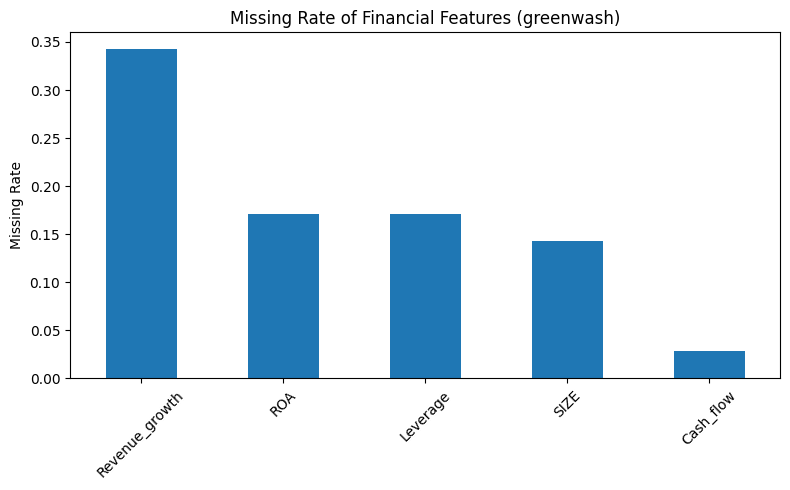


=== 輸出完成 ===
1. greenwash_missing_detail.csv
2. greenwash_core_missing_rows.csv
3. greenwash_missing_company_summary.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 讀取資料
# =========================
df = pd.read_csv("company_list_mix_with_financials_enhanced_fixed.csv")

# =========================
# 2. 欄位設定
# =========================
label_col = "type"   # 你的標籤欄位
positive_label = "greenwash"

company_col = "Company"
ticker_col = "ticker"
year_col = "Year"

financial_cols = ["SIZE", "ROA", "Leverage", "Revenue_growth", "Cash_flow"]
core_cols = ["SIZE", "ROA", "Leverage"]

# =========================
# 3. 先看 type 有哪些值
# =========================
print("\n=== type 欄位唯一值 ===")
print(df[label_col].value_counts(dropna=False))

# =========================
# 4. 分出 greenwash / 非 greenwash
# =========================
greenwash_df = df[df[label_col] == positive_label].copy()
non_greenwash_df = df[df[label_col] != positive_label].copy()

print("\n=== 基本樣本數 ===")
print("greenwash 筆數：", len(greenwash_df))
print("non-greenwash 筆數：", len(non_greenwash_df))

# =========================
# 5. greenwash 各財務欄位缺值數與比例
# =========================
print("\n=== greenwash 各財務欄位缺值數 ===")
print(greenwash_df[financial_cols].isna().sum())

print("\n=== greenwash 各財務欄位缺值比例 ===")
print(greenwash_df[financial_cols].isna().mean().round(3))

# =========================
# 6. non-greenwash 對照
# =========================
print("\n=== non-greenwash 各財務欄位缺值比例 ===")
print(non_greenwash_df[financial_cols].isna().mean().round(3))

# =========================
# 7. 核心缺值比例（最重要）
# =========================
greenwash_core_missing_ratio = greenwash_df[core_cols].isna().any(axis=1).mean()
non_greenwash_core_missing_ratio = non_greenwash_df[core_cols].isna().any(axis=1).mean()

print("\n=== 核心缺值比例（SIZE / ROA / Leverage）===")
print("greenwash:", round(greenwash_core_missing_ratio, 3))
print("non-greenwash:", round(non_greenwash_core_missing_ratio, 3))

# =========================
# 8. greenwash 中：只缺 Revenue_growth
# =========================
greenwash_only_growth = greenwash_df[
    greenwash_df["Revenue_growth"].isna() &
    greenwash_df[["SIZE", "ROA", "Leverage", "Cash_flow"]].notna().all(axis=1)
].copy()

print("\n=== greenwash 只缺 Revenue_growth ===")
print("筆數：", len(greenwash_only_growth))
print("公司數：", greenwash_only_growth[company_col].nunique())

# =========================
# 9. greenwash 中：核心缺值樣本
# =========================
greenwash_core_missing = greenwash_df[
    greenwash_df[core_cols].isna().any(axis=1)
].copy()

print("\n=== greenwash 核心缺值樣本數 ===")
print("筆數：", len(greenwash_core_missing))
print("公司數：", greenwash_core_missing[company_col].nunique())

# =========================
# 10. greenwash 缺值詳細清單
# =========================
def get_missing_fields(row):
    return [col for col in financial_cols if pd.isna(row[col])]

greenwash_missing = greenwash_df[
    greenwash_df[financial_cols].isna().any(axis=1)
].copy()

greenwash_missing["missing_fields"] = greenwash_missing.apply(get_missing_fields, axis=1)
greenwash_missing["num_missing"] = greenwash_missing["missing_fields"].apply(len)

greenwash_missing_detail = greenwash_missing[
    [company_col, ticker_col, year_col, label_col, "missing_fields", "num_missing"]
].sort_values(
    by=["num_missing", company_col, year_col],
    ascending=[False, True, True]
).reset_index(drop=True)

print("\n=== greenwash 缺值詳細清單 ===")
if len(greenwash_missing_detail) == 0:
    print("沒有 greenwash 缺值樣本")
else:
    print(greenwash_missing_detail.to_string(index=False))

# =========================
# 11. greenwash 核心缺值公司統計
# =========================
print("\n=== greenwash 核心缺值公司統計 ===")
if len(greenwash_core_missing) == 0:
    print("沒有 greenwash 核心缺值")
else:
    print(greenwash_core_missing[company_col].value_counts())

# =========================
# 12. 每家公司缺值次數（greenwash）
# =========================
if len(greenwash_missing) > 0:
    company_detail_rows = []
    for (company, ticker), group in greenwash_missing.groupby([company_col, ticker_col]):
        counts = group[financial_cols].isna().sum().to_dict()
        company_detail_rows.append({
            "Company": company,
            "ticker": ticker,
            "rows_with_missing": len(group),
            "SIZE_missing": counts["SIZE"],
            "ROA_missing": counts["ROA"],
            "Leverage_missing": counts["Leverage"],
            "Revenue_growth_missing": counts["Revenue_growth"],
            "Cash_flow_missing": counts["Cash_flow"],
        })

    greenwash_company_detail = pd.DataFrame(company_detail_rows).sort_values(
        by=["rows_with_missing", "Revenue_growth_missing", "SIZE_missing"],
        ascending=False
    ).reset_index(drop=True)

    print("\n=== greenwash 缺值公司摘要 ===")
    print(greenwash_company_detail.to_string(index=False))
else:
    greenwash_company_detail = pd.DataFrame()

# =========================
# 13. 畫圖：greenwash 缺值率
# =========================
missing_rates = greenwash_df[financial_cols].isna().mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
missing_rates.plot(kind="bar")
plt.title("Missing Rate of Financial Features (greenwash)")
plt.ylabel("Missing Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 14. 輸出 CSV
# =========================
greenwash_missing_detail.to_csv("greenwash_missing_detail.csv", index=False, encoding="utf-8-sig")
greenwash_core_missing.to_csv("greenwash_core_missing_rows.csv", index=False, encoding="utf-8-sig")
if len(greenwash_company_detail) > 0:
    greenwash_company_detail.to_csv("greenwash_missing_company_summary.csv", index=False, encoding="utf-8-sig")

print("\n=== 輸出完成 ===")
print("1. greenwash_missing_detail.csv")
print("2. greenwash_core_missing_rows.csv")
if len(greenwash_company_detail) > 0:
    print("3. greenwash_missing_company_summary.csv")

In [4]:
import pandas as pd

# =========================
# 1. 讀資料
# =========================
df = pd.read_csv("company_list_mix_with_financials_enhanced_fixed.csv")

# =========================
# 2. 財務欄位
# =========================
financial_cols = ["SIZE", "ROA", "Leverage", "Revenue_growth", "Cash_flow"]

company_col = "Company"
ticker_col = "ticker"

# =========================
# 3. 找有缺值的列
# =========================
missing_df = df[df[financial_cols].isna().any(axis=1)].copy()

# =========================
# 4. 列出「唯一公司」
# =========================
missing_companies = (
    missing_df[[company_col, ticker_col]]
    .drop_duplicates()
    .sort_values(by=company_col)
    .reset_index(drop=True)
)

print("\n=== 有缺財務資料的公司（unique）===")
print(missing_companies.to_string(index=False))

print("\n總公司數：", missing_companies.shape[0])


=== 有缺財務資料的公司（unique）===
                                            Company    ticker
                                         3M Company       MMM
                                   A.G. Barr p.l.c.     BAG.L
                                              ASICS    7936.T
                                             Adidas     ADDYY
                          Albertsons Companies, Inc       ACI
                                              Alpro     BN.PA
                                        Amer Sports        AS
                     Archer Daniels Midland Company       ADM
                                  Arctic Paper S.A.   ARCT.ST
                        Ausnutria Dairy Corporation   1717.HK
                         Avery Dennison Corporation       AVY
                                            BRF S.A      BRFS
                                BYD Company Limited     BYDDY
                                    Bega Cheese Ltd    BGA.AX
                                  Burlington

In [5]:
# =========================
# 5. 每家公司缺哪些欄位
# =========================
def get_missing_cols(group):
    return list(group[financial_cols].isna().sum()[lambda x: x > 0].index)

company_missing_detail = (
    missing_df.groupby([company_col, ticker_col])
    .apply(get_missing_cols)
    .reset_index(name="missing_fields")
    .sort_values(by=company_col)
)

print("\n=== 每家公司缺哪些欄位 ===")
print(company_missing_detail.to_string(index=False))

print("\n總公司數：", company_missing_detail.shape[0])


=== 每家公司缺哪些欄位 ===
                                            Company    ticker                                   missing_fields
                                         3M Company       MMM                                 [Revenue_growth]
                                   A.G. Barr p.l.c.     BAG.L                                 [Revenue_growth]
                                              ASICS    7936.T                                 [Revenue_growth]
                                             Adidas     ADDYY                                 [Revenue_growth]
                          Albertsons Companies, Inc       ACI                                 [Revenue_growth]
                                              Alpro     BN.PA            [SIZE, ROA, Leverage, Revenue_growth]
                                        Amer Sports        AS                                 [Revenue_growth]
                     Archer Daniels Midland Company       ADM            [SIZE, ROA, Leverage

In [6]:
# =========================
# 6. 缺值嚴重程度排序
# =========================
company_missing_detail["num_missing_fields"] = company_missing_detail["missing_fields"].apply(len)

priority_list = company_missing_detail.sort_values(
    by="num_missing_fields",
    ascending=False
)

print("\n=== 優先補資料公司（由嚴重到輕）===")
print(priority_list.to_string(index=False))


=== 優先補資料公司（由嚴重到輕）===
                                            Company    ticker                                   missing_fields  num_missing_fields
                                            BRF S.A      BRFS [SIZE, ROA, Leverage, Revenue_growth, Cash_flow]                   5
                                                jbs     JBSAY [SIZE, ROA, Leverage, Revenue_growth, Cash_flow]                   5
                                           Gap Inc.       GPS [SIZE, ROA, Leverage, Revenue_growth, Cash_flow]                   5
                            Yakult Honsha Co., Ltd.    2267.T [SIZE, ROA, Leverage, Revenue_growth, Cash_flow]                   5
                                           Skechers       SKX [SIZE, ROA, Leverage, Revenue_growth, Cash_flow]                   5
                                        Hanesbrands       HBI [SIZE, ROA, Leverage, Revenue_growth, Cash_flow]                   5
                                          Nordstrom       JW